In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
import random
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras import regularizers
from keras.callbacks import EarlyStopping

In [2]:
# Load dataset
df = pd.read_csv("ExtNet.csv", header=0)

df

,5,10,15,20,25,30,35,40
0,0.625823,0.209345,0.316992,0.741699,0.401142,0.504226,0.436550,0.455820
1,0.511651,0.082433,0.121866,0.388198,0.107865,0.208056,0.307003,0.292884
2,0.862449,0.220179,0.238725,0.745637,0.090144,0.508926,0.225226,0.136413
3,0.403072,0.293388,0.173261,0.330954,0.310926,0.264051,0.551141,0.123431
4,0.111646,0.149352,-0.075565,0.174732,0.159857,-0.112117,-0.123742,-0.056884
...,...,...,...,...,...,...,...,...
7555,-0.134700,-0.182980,-0.085060,-0.009070,-0.310800,-0.153020,0.172860,0.023608
7556,0.089562,0.146758,-0.041260,0.037358,-0.082550,0.049539,0.041604,-0.049240
7557,0.121303,-0.030670,0.068472,0.182569,-0.114810,-0.070730,0.159934,0.284742
7558,0.205227,-0.015830,-0.047760,-0.084750,-0.224710,0.130341,0.056592,0.093048


### Putting in loop to make heatmap

In [19]:
cluster_array = [50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,1000]
size_array = [50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,1000]

In [20]:
def create_heatmap(cluster,number):
    num_clusters = cluster
    cluster_size = number
    num_samples = num_clusters * cluster_size
    resampled_df = df.sample(n=num_samples, replace=True, random_state = 42).reset_index(drop=True)

    shuf_mat = resampled_df.T.to_numpy()

    y = []
    values = list(range(8))  # Generates [0, 1, 2, 3, 4, 5, 6, 7]

    for value in values:
        y.extend([value] * num_clusters)  
    y = np.array(y)

    x = []

    for k in range(8):
        for j in range(num_clusters):
            temp = []
            start_idx = j * cluster_size  
            for i in range(cluster_size):
                temp.append(shuf_mat[k][start_idx+i]) 
            x.append(temp) 
    X = np.array(x)

    #Best: 0.3 test size, 50 epochs, batch size 32
    # Define dataset parameters
    num_groups = 8  
    group_size = num_clusters  
    num_features = cluster_size  
    
    random.seed(42)
    np.random.seed(42)
    tf.random.set_seed(42)
    
    # Create group IDs (0-7, each repeated 70 times)
    group_labels = np.repeat(np.arange(num_groups), group_size)  
    
    # Split data while preserving group structure
    X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
        X, y, group_labels, test_size=0.3, random_state=42, stratify=group_labels
    )
    
    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Convert labels to categorical (one-hot encoding)
    y_train_categorical = keras.utils.to_categorical(y_train, len(np.unique(y)))
    y_test_categorical = keras.utils.to_categorical(y_test, num_classes=8)
    
    
    # Build ANN model
    model = Sequential([
        Dense(128, activation='sigmoid', input_shape=(num_features,),kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(8, activation='softmax')  # 8 output classes
    ])
    
    # Define EarlyStopping callback
    early_stop = EarlyStopping(
        monitor='val_loss',       # what to monitor
        patience=10,               # how many epochs to wait after last improvement
        restore_best_weights=True # restore model weights from the best epoch
    )
    
    
    #.425 = .35 acc
    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model
    #history = model.fit(X_train, y_train_categorical, epochs=100, batch_size=32, validation_data=(X_test, y_test_categorical))
    history = model.fit(X_train, y_train_categorical, epochs=100, batch_size=32,validation_data=(X_test, y_test_categorical),callbacks=[early_stop])
    
    # Make predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Evaluate model performance
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    
    return accuracy



In [21]:
accuracy_heatmap = []
for c in range(len(cluster_array)):
    for d in range(len(size_array)):
        acc_value = create_heatmap(cluster_array[c],size_array[d])
        accuracy_heatmap.append(acc_value)
        

Epoch 1/100


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1109 - loss: 2.2810 - val_accuracy: 0.2000 - val_loss: 2.1361
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1506 - loss: 2.1719 - val_accuracy: 0.1917 - val_loss: 2.1349
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1728 - loss: 2.1340 - val_accuracy: 0.1667 - val_loss: 2.1240
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2162 - loss: 2.1299 - val_accuracy: 0.1917 - val_loss: 2.1109
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1975 - loss: 2.1031 - val_accuracy: 0.2167 - val_loss: 2.0928
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1607 - loss: 2.1306 - val_accuracy: 0.2500 - val_loss: 2.0798
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1910 - loss: 2.0910 - val_accuracy: 0.2417 - val_loss: 2.0598
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1381 - loss: 2.1024 - val_accuracy: 0.2333 - val_loss: 2.0406
Epoch 9/100

/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1078 - loss: 2.3292 - val_accuracy: 0.1917 - val_loss: 2.1730
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1645 - loss: 2.1928 - val_accuracy: 0.1500 - val_loss: 2.1607
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1912 - loss: 2.1568 - val_accuracy: 0.1833 - val_loss: 2.1512
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1749 - loss: 2.1692 - val_accuracy: 0.2250 - val_loss: 2.1353
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1641 - loss: 2.1450 - val_accuracy: 0.2500 - val_loss: 2.1154
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1993 - loss: 2.1353 - val_accuracy: 0.2333 - val_loss: 2.0898
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2509 - loss: 2.0691 - val_accuracy: 0.2333 - val_loss: 2.0536
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2190 - loss: 2.0795 - val_accuracy: 0.2667 - val_loss: 1.9972
Epoch 9/100

...

Epoch 1/100


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2636 - loss: 2.0459 - val_accuracy: 0.5779 - val_loss: 1.1139
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5325 - loss: 1.1996 - val_accuracy: 0.6204 - val_loss: 0.9347
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5881 - loss: 1.0118 - val_accuracy: 0.6354 - val_loss: 0.8799
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6152 - loss: 0.9221 - val_accuracy: 0.6254 - val_loss: 0.8808
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6305 - loss: 0.8428 - val_accuracy: 0.6192 - val_loss: 0.8871
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6602 - loss: 0.8436 - val_accuracy: 0.6375 - val_loss: 0.8717
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6795 - loss: 0.7873 - val_accuracy: 0.6338 - val_loss: 0.9029
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6939 - loss: 0.7431 - val_accuracy: 0.6321

/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2675 - loss: 2.0395 - val_accuracy: 0.5804 - val_loss: 1.1218
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5378 - loss: 1.1824 - val_accuracy: 0.6100 - val_loss: 0.9301
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6018 - loss: 0.9751 - val_accuracy: 0.6342 - val_loss: 0.8800
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6305 - loss: 0.8998 - val_accuracy: 0.6271 - val_loss: 0.8734
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6629 - loss: 0.8189 - val_accuracy: 0.6350 - val_loss: 0.8964
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6805 - loss: 0.7828 - val_accuracy: 0.5908 - val_loss: 0.9498
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6757 - loss: 0.7731 - val_accuracy: 0.6221 - val_loss: 0.9115
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6807 - loss: 0.7540 - val_accuracy: 0.6162

In [22]:
print(accuracy_heatmap)

[0.30833333333333335, 0.4083333333333333, 0.44166666666666665, 0.35833333333333334, 0.4583333333333333, 0.4, 0.4166666666666667, 0.4583333333333333, 0.4083333333333333, 0.3333333333333333, 0.4, 0.38333333333333336, 0.3333333333333333, 0.4583333333333333, 0.425, 0.35, 0.35833333333333334, 0.36666666666666664, 0.30833333333333335, 0.2916666666666667, 0.3458333333333333, 0.3125, 0.3875, 0.4166666666666667, 0.44583333333333336, 0.44583333333333336, 0.5375, 0.48333333333333334, 0.4791666666666667, 0.5583333333333333, 0.4875, 0.4666666666666667, 0.45416666666666666, 0.5208333333333334, 0.45416666666666666, 0.5, 0.4583333333333333, 0.5083333333333333, 0.4875, 0.4666666666666667, 0.32222222222222224, 0.36666666666666664, 0.38055555555555554, 0.4527777777777778, 0.4166666666666667, 0.44722222222222224, 0.5111111111111111, 0.44722222222222224, 0.5361111111111111, 0.5027777777777778, 0.5194444444444445, 0.5222222222222223, 0.55, 0.5361111111111111, 0.5194444444444445, 0.5333333333333333, 0.516666

In [23]:
reshaped = np.reshape(accuracy_heatmap,(20,20))

In [24]:
print(reshaped)

[[0.30833333 0.40833333 0.44166667 0.35833333 0.45833333 0.4
  0.41666667 0.45833333 0.40833333 0.33333333 0.4        0.38333333
  0.33333333 0.45833333 0.425      0.35       0.35833333 0.36666667
  0.30833333 0.29166667]
 [0.34583333 0.3125     0.3875     0.41666667 0.44583333 0.44583333
  0.5375     0.48333333 0.47916667 0.55833333 0.4875     0.46666667
  0.45416667 0.52083333 0.45416667 0.5        0.45833333 0.50833333
  0.4875     0.46666667]
 [0.32222222 0.36666667 0.38055556 0.45277778 0.41666667 0.44722222
  0.51111111 0.44722222 0.53611111 0.50277778 0.51944444 0.52222222
  0.55       0.53611111 0.51944444 0.53333333 0.51666667 0.56944444
  0.51944444 0.52222222]
 [0.32083333 0.35416667 0.40416667 0.43125    0.43333333 0.46041667
  0.49791667 0.52708333 0.51666667 0.54583333 0.51875    0.51875
  0.54791667 0.57291667 0.58333333 0.55208333 0.575      0.60833333
  0.58125    0.55833333]
 [0.29666667 0.37833333 0.39166667 0.43666667 0.45       0.51333333
  0.45       0.51666667 0.

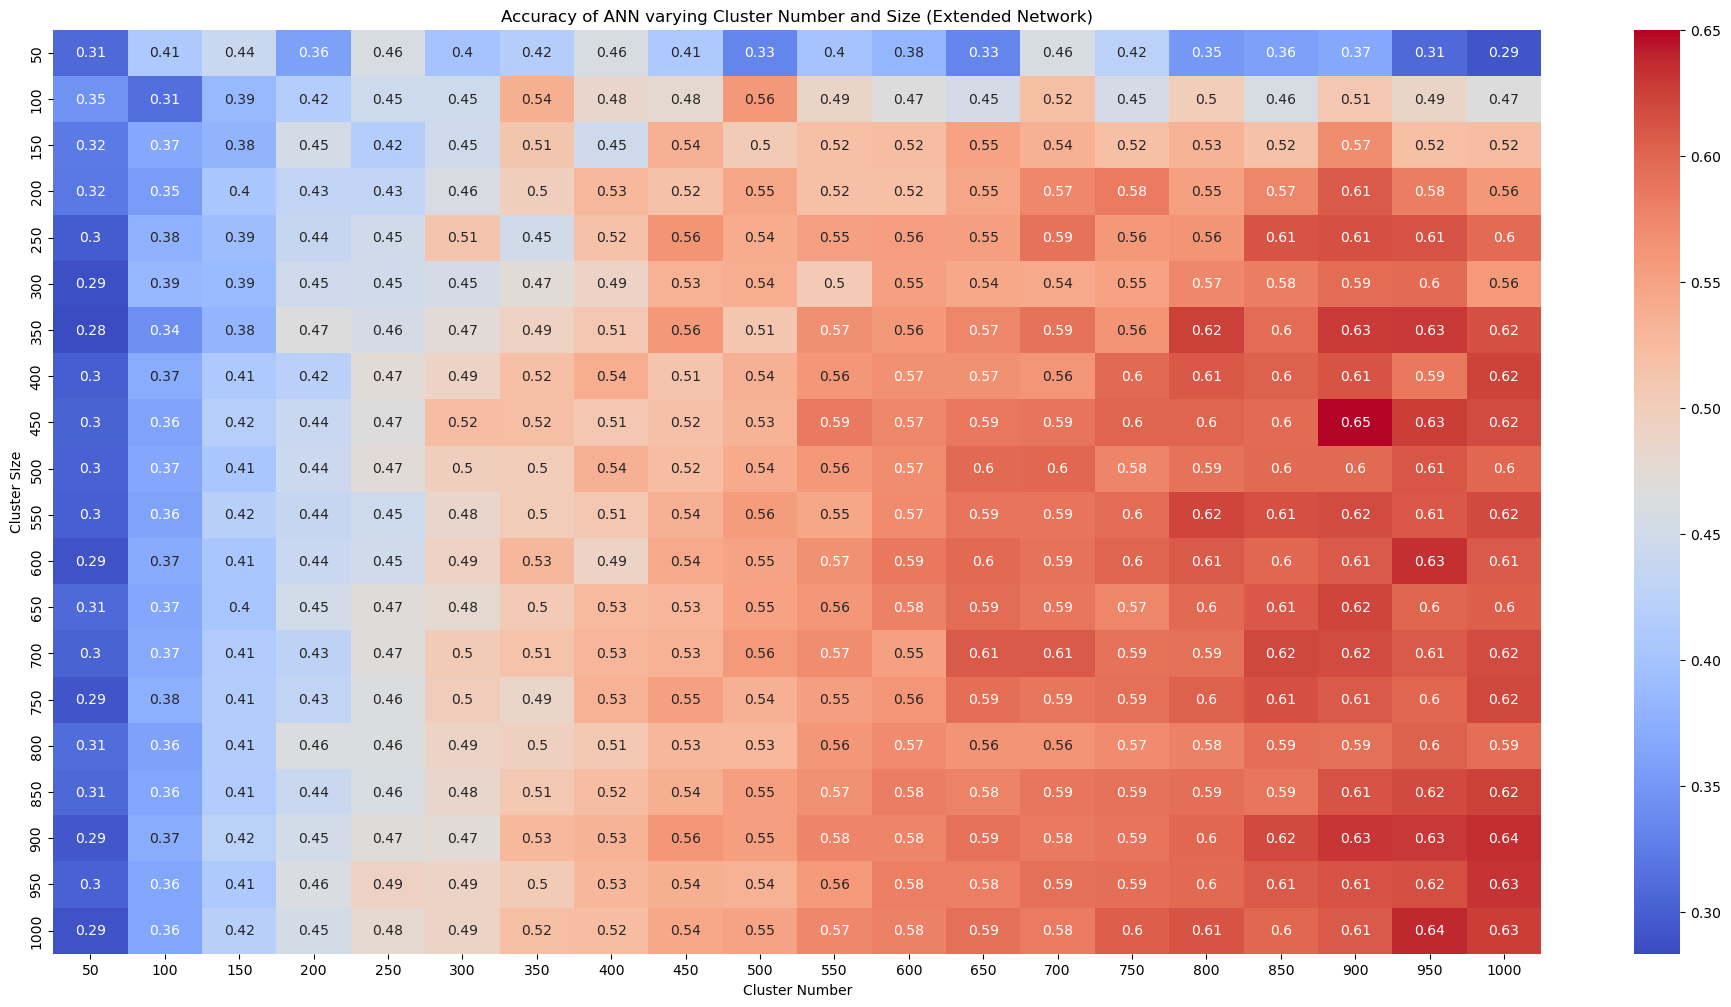

In [26]:
plt.figure(figsize=(24, 12))
sns.heatmap(reshaped, annot=True, annot_kws={"size": 10}, cmap="coolwarm",xticklabels=['50','100','150','200','250','300','350','400','450','500','550','600','650','700','750','800','850','900','950','1000'],
            yticklabels=['50','100','150','200','250','300','350','400','450','500','550','600','650','700','750','800','850','900','950','1000'])
plt.xlabel("Cluster Number")
plt.ylabel("Cluster SIze")
plt.title("Accuracy of ANN varying Cluster Number and Size (Extended Network)")
plt.show()

### Single Run at a Time

In [ ]:
num_clusters = 20000
cluster_size = 20000
num_samples = num_clusters * cluster_size
resampled_df = df.sample(n=num_samples, replace=True, random_state = 42).reset_index(drop=True)

In [ ]:
resampled_df

In [ ]:
shuf_mat = resampled_df.T.to_numpy()
shuf_mat.shape

In [ ]:
print(shuf_mat)

### Code for Labels after Shuffling

In [ ]:
y = []
values = list(range(8))  # Generates [0, 1, 2, 3, 4, 5, 6, 7]

for value in values:
    y.extend([value] * num_clusters) 


In [ ]:
y = np.array(y)
print(y)

In [ ]:
len(y)

### Code for creating X after Shuffling

In [ ]:
x = []

for k in range(8):
    for j in range(num_clusters):
        temp = []
        start_idx = j * cluster_size  
        for i in range(cluster_size):
            temp.append(shuf_mat[k][start_idx+i]) 
        x.append(temp) 
print(len(x))

In [ ]:
X = np.array(x)
X.shape

### Running ANN with Early Stopping

In [ ]:
#Best: 0.3 test size, 50 epochs, batch size 32
# Define dataset parameters
num_groups = 8  
group_size = num_clusters  
num_features = cluster_size  

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Create group IDs (0-7, each repeated 70 times)
group_labels = np.repeat(np.arange(num_groups), group_size)  

# Split data while preserving group structure
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X, y, group_labels, test_size=0.3, random_state=42, stratify=group_labels
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to categorical (one-hot encoding)
y_train_categorical = keras.utils.to_categorical(y_train, len(np.unique(y)))
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=8)


# Build ANN model
model = Sequential([
    Dense(128, activation='sigmoid', input_shape=(num_features,),kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='softmax')  # 8 output classes
])

# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',       # what to monitor
    patience=10,               # how many epochs to wait after last improvement
    restore_best_weights=True # restore model weights from the best epoch
)


#.425 = .35 acc
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
#history = model.fit(X_train, y_train_categorical, epochs=100, batch_size=32, validation_data=(X_test, y_test_categorical))
history = model.fit(X_train, y_train_categorical, epochs=100, batch_size=32,validation_data=(X_test, y_test_categorical),callbacks=[early_stop])

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(8), yticklabels=range(8))
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot training history (Accuracy)
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy Over Epochs')
plt.show()

# Plot training history (Loss)
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss Over Epochs')
plt.show()


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5016 - loss: 1.4561 - val_accuracy: 0.6940 - val_loss: 1.1379
Epoch 2/100
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6728 - loss: 1.2112 - val_accuracy: 0.7270 - val_loss: 1.1593
Epoch 3/100
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7066 - loss: 1.2177 - val_accuracy: 0.7253 - val_loss: 1.2310
Epoch 4/100
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7300 - loss: 1.2419 - val_accuracy: 0.7142 - val_loss: 1.2567
Epoch 5/100
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7373 - loss: 1.2609 - val_accuracy: 0.7193 - val_loss: 1.2707
Epoch 6/100
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7478 - loss: 1.2643 - val_accuracy: 0.7280 - val_loss: 1.3131
Epoch 7/100
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7525 - loss: 1.2685 - val_accuracy: 0.7360 - val_loss: 1.2876
Epoch 8/100
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7634 - loss: 1

/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

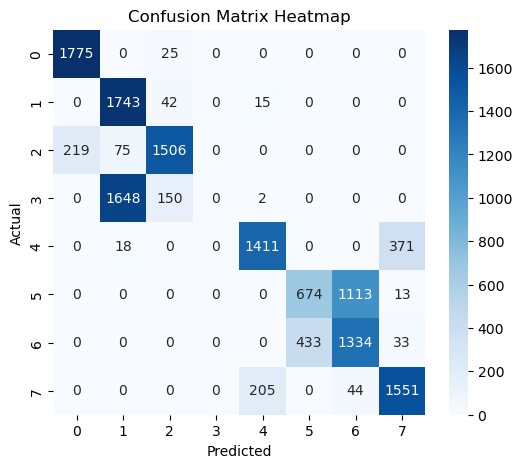

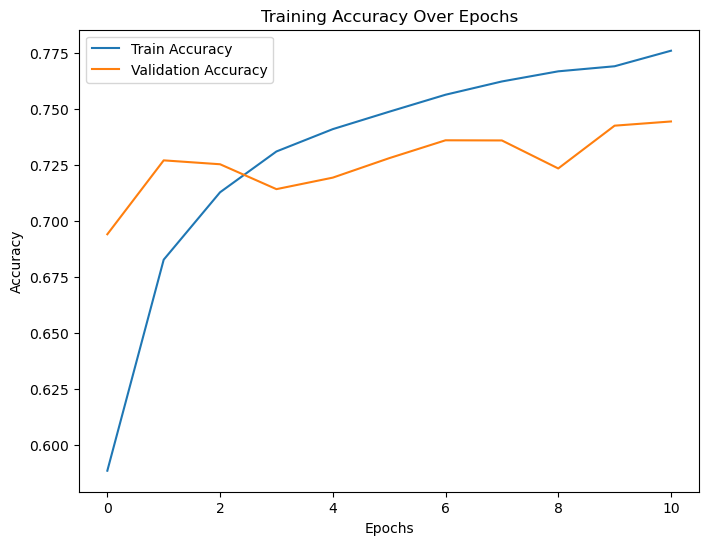

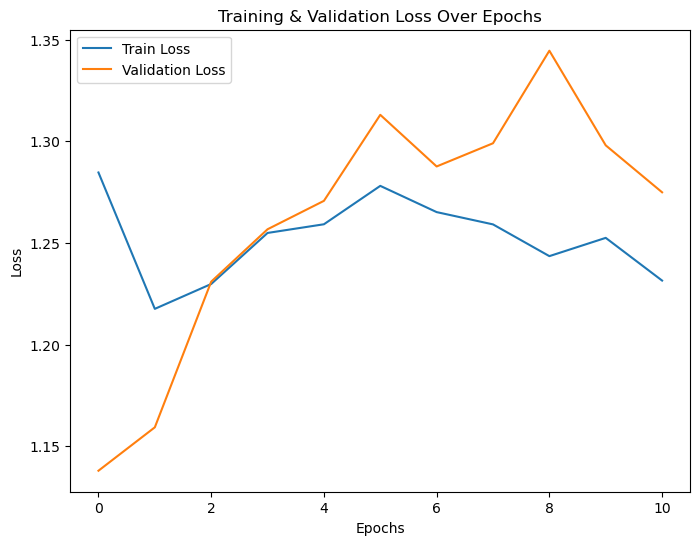

In [14]:
#Best: 0.3 test size, 50 epochs, batch size 32
# Define dataset parameters
num_groups = 8  
group_size = num_clusters  
num_features = cluster_size  
    
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
    
# Create group IDs (0-7, each repeated 70 times)
group_labels = np.repeat(np.arange(num_groups), group_size)  
    
# Split data while preserving group structure
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
     X, y, group_labels, test_size=0.3, random_state=42, stratify=group_labels
)
    
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
    
# Convert labels to categorical (one-hot encoding)
y_train_categorical = keras.utils.to_categorical(y_train, len(np.unique(y)))
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=8)
    
    
# Build ANN model
model = Sequential([
    Dense(128, activation='sigmoid', input_shape=(num_features,),kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='softmax')  # 8 output classes
])
    
# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',       # what to monitor
    patience=10,               # how many epochs to wait after last improvement
    restore_best_weights=True # restore model weights from the best epoch
)
    
    
#.425 = .35 acc
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
# Train the model
 #history = model.fit(X_train, y_train_categorical, epochs=100, batch_size=32, validation_data=(X_test, y_test_categorical))
history = model.fit(X_train, y_train_categorical, epochs=100, batch_size=32,validation_data=(X_test, y_test_categorical),callbacks=[early_stop])
    
# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
    
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(8), yticklabels=range(8))
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot training history (Accuracy)
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy Over Epochs')
plt.show()

# Plot training history (Loss)
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss Over Epochs')
plt.show()
